 1. Object Detection with YOLOv5 (Using Pretrained Weights)

 Problem: Detect objects using pre-trained YOLOv5 model.


image 1/1 D:\HopeAI\Assignments\6 DeepLearningWeek11\1.Deep_Learning_Question_Set2\4.Coding\Images_to_use\val\1106_png.rf.12946e4962a85e4c8574d978ba6328e0.jpg: 640x640 1 horse, 118.1ms
Speed: 8.3ms preprocess, 118.1ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


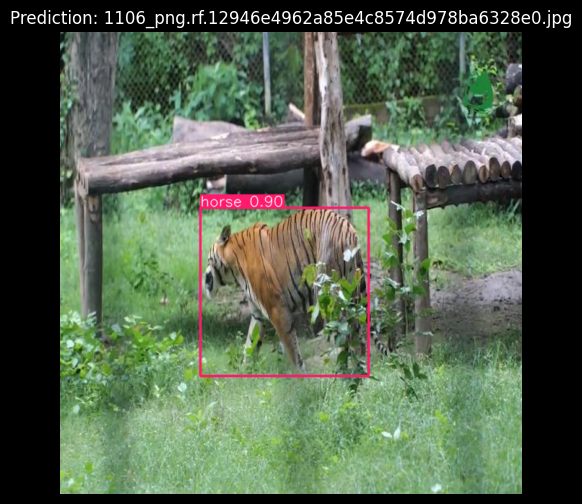

In [23]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# Load model
model = YOLO('yolov5su.pt')  # Small YOLOv5 model

img_path = r"D:\HopeAI\Assignments\6 DeepLearningWeek11\1.Deep_Learning_Question_Set2\4.Coding\Images_to_use\val\1106_png.rf.12946e4962a85e4c8574d978ba6328e0.jpg"
results = model(img_path)  # Image path

# Get annotated image (numpy array, BGR)
annotated = results[0].plot()

# Convert BGR → RGB for matplotlib
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(annotated)
plt.axis("off")
plt.title(f"Prediction: {os.path.basename(img_path)}")
plt.show()


 2.Preprocessing Image for ResNet Input

 Problem: Write a function to preprocess image for pretrained ResNet.

In [24]:
from torchvision import transforms
from PIL import Image

def preprocess_image(img_path):
    image = Image.open(img_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0)


 3. CNN for CIFAR-10 Classification

 Problem: Build a CNN model to classify CIFAR-10 images.

In [26]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))


 4. Scenario: Face Mask Detection – Real-Time Webcam Classifier

 Problem: Build a real-time face mask detector using a trained CNN model and OpenCV.

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("model.h5", compile=False)

cap = cv2.VideoCapture(1)
while True:
    _, frame = cap.read()
    face = cv2.resize(frame, (224, 224)) / 255.0
    prediction = model.predict(np.expand_dims(face, axis=0))[0][0]
    label = "Mask" if prediction < 0.5 else "No Mask"

    cv2.putText(frame, label, (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    cv2.imshow("Face Mask Detection", frame)
    if cv2.waitKey(1) == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()


 5. Scenario: Custom Transfer Learning with Frozen + Trainable Layers

 Problem: Load a pretrained MobileNetV2 model, freeze base layers, add custom classifier, and fine-tune the top few layers.

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
